# Pass Map — Robin Aime Robert Le Normand

Ce notebook génère une pass map à partir des données événementielles StatsBomb Open Data.

Objectif : visualiser les passes d’un défenseur central avec des flèches représentant la direction de chaque passe.

- Passes réussies : vert
- Passes ratées : rouge

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from statsbombpy import sb
from mplsoccer import Pitch

In [2]:
COMPETITION_ID = 55
SEASON_ID = 282
MATCH_ID = 3943043

PLAYER_NAME = "Robin Aime Robert Le Normand"
DATA_SOURCE = "StatsBomb Open Data"
EVENT_TYPE = "Pass"
ANALYSIS_TYPE = "Pass map"

In [3]:
competitions = sb.competitions()

selected_competition = competitions[
    (competitions["competition_id"] == COMPETITION_ID)
    & (competitions["season_id"] == SEASON_ID)
].iloc[0]

COMPETITION_NAME = selected_competition["competition_name"]
SEASON_NAME = selected_competition["season_name"]
COUNTRY_NAME = selected_competition["country_name"]

COMPETITION_NAME, SEASON_NAME, COUNTRY_NAME

('UEFA Euro', '2024', 'Europe')

In [4]:
matches = sb.matches(
    competition_id=COMPETITION_ID,
    season_id=SEASON_ID
)

selected_match = matches[
    matches["match_id"] == MATCH_ID
].iloc[0]

MATCH_DATE = selected_match["match_date"]
HOME_TEAM = selected_match["home_team"]
AWAY_TEAM = selected_match["away_team"]
HOME_SCORE = selected_match["home_score"]
AWAY_SCORE = selected_match["away_score"]
COMPETITION_STAGE = selected_match["competition_stage"]

MATCH_LABEL = f"{HOME_TEAM} {HOME_SCORE} - {AWAY_SCORE} {AWAY_TEAM}"

MATCH_LABEL, MATCH_DATE, COMPETITION_STAGE

('Spain 2 - 1 England', '2024-07-14', 'Final')

In [5]:
events = sb.events(match_id=MATCH_ID)

events.shape

(3312, 92)

In [6]:
events["type"].value_counts().head(20)

type
Pass               917
Ball Receipt*      878
Carry              759
Pressure           327
Ball Recovery       71
Duel                70
Block               43
Clearance           43
Goal Keeper         30
Shot                25
Dribble             24
Dispossessed        23
Foul Committed      19
Foul Won            19
Miscontrol          12
Dribbled Past       10
Interception         7
Substitution         7
Injury Stoppage      6
Half Start           4
Name: count, dtype: int64

In [7]:
players = (
    events[["team", "player", "position"]]
    .dropna()
    .drop_duplicates()
    .sort_values(["team", "player"])
)

players[
    players["player"].str.contains("Le Normand", case=False, na=False)
]

,team,player,position
9,Spain,Robin Aime Robert Le Normand,Right Center Back


In [8]:
passes = events[
    events["type"] == "Pass"
].copy()

passes.shape

(917, 92)

In [9]:
passes[
    [
        "team",
        "player",
        "position",
        "minute",
        "second",
        "location",
        "pass_end_location",
        "pass_outcome",
        "pass_length",
        "pass_angle",
        "pass_height",
        "pass_recipient"
    ]
].head()

,team,player,position,minute,second,location,pass_end_location,pass_outcome,pass_length,pass_angle,pass_height,pass_recipient
6,England,Kobbie Mainoo,Right Defensive Midfield,0,0,"[60.0, 40.0]","[25.4, 38.8]",NaN,34.620804,-3.106924,Ground Pass,Jordan Pickford
7,England,Jordan Pickford,Goalkeeper,0,4,"[28.7, 31.6]","[120.0, 67.7]",Out,98.177900,0.376534,High Pass,Bukayo Saka
8,Spain,Unai Simón Mendibil,Goalkeeper,0,34,"[6.9, 39.6]","[9.1, 57.2]",NaN,17.736967,1.446441,Ground Pass,Robin Aime Robert Le Normand
9,Spain,Robin Aime Robert Le Normand,Right Center Back,0,36,"[8.9, 57.2]","[20.6, 75.8]",NaN,21.973848,1.009303,Ground Pass,Daniel Carvajal Ramos
10,Spain,Daniel Carvajal Ramos,Right Back,0,39,"[28.6, 76.4]","[50.2, 68.5]",NaN,22.999348,-0.350628,Ground Pass,Daniel Olmo Carvajal


In [10]:
player_passes = passes[
    passes["player"] == PLAYER_NAME
].copy()

player_passes.shape

(84, 92)

In [11]:
len(player_passes)

84

In [12]:
TEAM_NAME = player_passes["team"].mode()[0]
POSITION_NAME = player_passes["position"].mode()[0]

TEAM_NAME, POSITION_NAME

('Spain', 'Right Center Back')

In [13]:
def extract_coordinate(value, index):
    if isinstance(value, list) and len(value) > index:
        return value[index]
    return np.nan

In [14]:
player_passes["x"] = player_passes["location"].apply(
    lambda value: extract_coordinate(value, 0)
)

player_passes["y"] = player_passes["location"].apply(
    lambda value: extract_coordinate(value, 1)
)

player_passes["end_x"] = player_passes["pass_end_location"].apply(
    lambda value: extract_coordinate(value, 0)
)

player_passes["end_y"] = player_passes["pass_end_location"].apply(
    lambda value: extract_coordinate(value, 1)
)

In [15]:
player_passes["is_completed"] = player_passes["pass_outcome"].isna()

In [16]:
player_passes[
    [
        "team",
        "player",
        "position",
        "minute",
        "second",
        "x",
        "y",
        "end_x",
        "end_y",
        "pass_outcome",
        "is_completed"
    ]
].head()

,team,player,position,minute,second,x,y,end_x,end_y,pass_outcome,is_completed
9,Spain,Robin Aime Robert Le Normand,Right Center Back,0,36,8.9,57.2,20.6,75.8,NaN,True
17,Spain,Robin Aime Robert Le Normand,Right Center Back,1,8,23.3,60.1,27.4,33.8,NaN,True
19,Spain,Robin Aime Robert Le Normand,Right Center Back,1,22,42.9,54.1,43.5,25.2,NaN,True
25,Spain,Robin Aime Robert Le Normand,Right Center Back,1,50,29.0,67.8,34.9,76.0,NaN,True
30,Spain,Robin Aime Robert Le Normand,Right Center Back,2,21,29.2,64.7,3.8,45.5,NaN,True


In [17]:
player_passes["x_progression"] = player_passes["end_x"] - player_passes["x"]
player_passes["y_progression"] = player_passes["end_y"] - player_passes["y"]

player_passes["is_forward_pass"] = player_passes["x_progression"] > 0
player_passes["is_long_pass"] = player_passes["pass_length"] >= 30

In [18]:
player_passes[
    ["x", "y", "end_x", "end_y", "pass_length"]
].isna().sum()

x              0
y              0
end_x          0
end_y          0
pass_length    0
dtype: int64

In [19]:
assert len(player_passes) > 0, "No passes found for the selected player."

assert player_passes["x"].notna().all(), "Missing x coordinates."
assert player_passes["y"].notna().all(), "Missing y coordinates."
assert player_passes["end_x"].notna().all(), "Missing end_x coordinates."
assert player_passes["end_y"].notna().all(), "Missing end_y coordinates."

assert player_passes["player"].nunique() == 1, "More than one player found."
assert player_passes["player"].iloc[0] == PLAYER_NAME, "Selected player mismatch."

print("Quality checks passed.")

Quality checks passed.


In [20]:
player_passes_clean = player_passes[
    [
        "match_id",
        "team",
        "player",
        "position",
        "minute",
        "second",
        "x",
        "y",
        "end_x",
        "end_y",
        "pass_length",
        "pass_angle",
        "pass_height",
        "pass_outcome",
        "pass_recipient",
        "is_completed",
        "x_progression",
        "y_progression",
        "is_forward_pass",
        "is_long_pass"
    ]
].copy()

player_passes_clean.head()

,match_id,team,player,position,minute,second,x,y,end_x,end_y,pass_length,pass_angle,pass_height,pass_outcome,pass_recipient,is_completed,x_progression,y_progression,is_forward_pass,is_long_pass
9,3943043,Spain,Robin Aime Robert Le Normand,Right Center Back,0,36,8.9,57.2,20.6,75.8,21.973848,1.009303,Ground Pass,NaN,Daniel Carvajal Ramos,True,11.7,18.6,True,False
17,3943043,Spain,Robin Aime Robert Le Normand,Right Center Back,1,8,23.3,60.1,27.4,33.8,26.617662,-1.416148,Ground Pass,NaN,Aymeric Laporte,True,4.1,-26.3,True,False
19,3943043,Spain,Robin Aime Robert Le Normand,Right Center Back,1,22,42.9,54.1,43.5,25.2,28.906227,-1.550038,Ground Pass,NaN,Aymeric Laporte,True,0.6,-28.9,True,False
25,3943043,Spain,Robin Aime Robert Le Normand,Right Center Back,1,50,29.0,67.8,34.9,76.0,10.101980,0.947095,Ground Pass,NaN,Daniel Carvajal Ramos,True,5.9,8.2,True,False
30,3943043,Spain,Robin Aime Robert Le Normand,Right Center Back,2,21,29.2,64.7,3.8,45.5,31.840225,-2.494323,Ground Pass,NaN,Unai Simón Mendibil,True,-25.4,-19.2,False,True


In [21]:
total_passes = len(player_passes_clean)
completed_passes = int(player_passes_clean["is_completed"].sum())
incomplete_passes = total_passes - completed_passes

completion_rate = completed_passes / total_passes if total_passes > 0 else 0

forward_passes = int(player_passes_clean["is_forward_pass"].sum())
forward_pass_share = forward_passes / total_passes if total_passes > 0 else 0

long_passes = int(player_passes_clean["is_long_pass"].sum())
long_pass_share = long_passes / total_passes if total_passes > 0 else 0

average_pass_length = player_passes_clean["pass_length"].mean()

In [22]:
metrics_summary = pd.DataFrame(
    {
        "metric": [
            "Player",
            "Team",
            "Position",
            "Competition",
            "Season",
            "Match",
            "Match date",
            "Total passes",
            "Completed passes",
            "Incomplete passes",
            "Completion rate",
            "Forward passes",
            "Forward pass share",
            "Long passes",
            "Long pass share",
            "Average pass length"
        ],
        "value": [
            PLAYER_NAME,
            TEAM_NAME,
            POSITION_NAME,
            COMPETITION_NAME,
            SEASON_NAME,
            MATCH_LABEL,
            MATCH_DATE,
            total_passes,
            completed_passes,
            incomplete_passes,
            f"{completion_rate:.1%}",
            forward_passes,
            f"{forward_pass_share:.1%}",
            long_passes,
            f"{long_pass_share:.1%}",
            round(average_pass_length, 1)
        ]
    }
)

metrics_summary

,metric,value
0,Player,Robin Aime Robert Le Normand
1,Team,Spain
2,Position,Right Center Back
3,Competition,UEFA Euro
4,Season,2024
5,Match,Spain 2 - 1 England
6,Match date,2024-07-14
7,Total passes,84
8,Completed passes,80
9,Incomplete passes,4


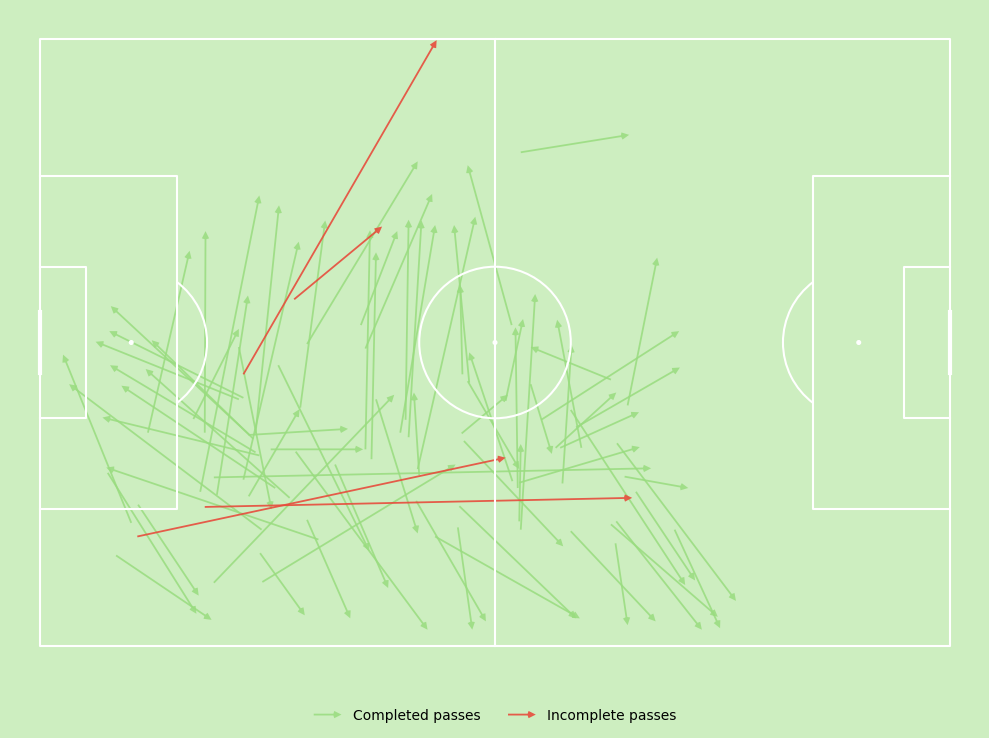

In [28]:
completed = player_passes_clean[
    player_passes_clean["is_completed"]
].copy()

incomplete = player_passes_clean[
    ~player_passes_clean["is_completed"]
].copy()

pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="#cdeec0",
    line_color="white",
    linewidth=1.5,
    line_zorder=3
)

fig, ax = pitch.draw(figsize=(10, 7.5))
fig.patch.set_facecolor("#cdeec0")

pitch.arrows(
    completed["x"],
    completed["y"],
    completed["end_x"],
    completed["end_y"],
    ax=ax,
    color="#99DC7F",
    width=1.3,
    headwidth=4,
    headlength=4,
    alpha=0.85,
    zorder=2,
    label="Completed passes"
)

pitch.arrows(
    incomplete["x"],
    incomplete["y"],
    incomplete["end_x"],
    incomplete["end_y"],
    ax=ax,
    color="#e74c3c",
    width=1.3,
    headwidth=4,
    headlength=4,
    alpha=0.90,
    zorder=2,
    label="Incomplete passes"
)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.03),
    ncol=2,
    frameon=False
)

plt.show()

In [45]:
def plot_pass_map(
    passes,
    player_name,
    team_name=None,
    season_label=None,
    match_label=None,
    match_date=None,
    source="StatsBomb Open Data",
    title=None,
    show_legend=True,
    arrow_width=1.3,
    arrow_alpha=0.85
):
    """
    Plot a pass map with arrows.

    Completed passes are shown in green.
    Incomplete passes are shown in red.
    """

    required_columns = ["x", "y", "end_x", "end_y", "is_completed"]

    missing_columns = [
        column for column in required_columns
        if column not in passes.columns
    ]

    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    plot_data = passes.dropna(
        subset=["x", "y", "end_x", "end_y"]
    ).copy()

    if plot_data.empty:
        raise ValueError("No valid pass coordinates available for plotting.")

    completed = plot_data[
        plot_data["is_completed"]
    ].copy()

    incomplete = plot_data[
        ~plot_data["is_completed"]
    ].copy()

    pitch_color = "#99DC7F"
    line_color = "white"

    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color=pitch_color,
        line_color=line_color,
        linewidth=1.5,
        line_zorder=4
    )

    fig, ax = pitch.draw(figsize=(10, 8.4))
    fig.patch.set_facecolor(pitch_color)
    ax.set_facecolor(pitch_color)

    # Plus d'espace en haut pour le texte
    # Plus d'espace en bas pour la flèche + la légende
    fig.subplots_adjust(top=0.42, bottom=0.24)

    if len(completed) > 0:
        pitch.arrows(
            completed["x"],
            completed["y"],
            completed["end_x"],
            completed["end_y"],
            ax=ax,
            color="#00a86b",
            width=arrow_width,
            headwidth=4,
            headlength=4,
            alpha=arrow_alpha,
            zorder=2,
            label="Completed passes"
        )

    if len(incomplete) > 0:
        pitch.arrows(
            incomplete["x"],
            incomplete["y"],
            incomplete["end_x"],
            incomplete["end_y"],
            ax=ax,
            color="#e74c3c",
            width=arrow_width,
            headwidth=4,
            headlength=4,
            alpha=arrow_alpha,
            zorder=2,
            label="Incomplete passes"
        )

    header_title = title or f"{player_name.upper()} — PASS MAP"

    subtitle_parts = []

    if team_name:
        subtitle_parts.append(team_name)

    if season_label:
        subtitle_parts.append(season_label)

    if match_label:
        subtitle_parts.append(match_label)

    if match_date:
        subtitle_parts.append(str(match_date))

    if source:
        subtitle_parts.append(source)

    header_subtitle = " | ".join(subtitle_parts)

    # Titre plus haut
    fig.text(
        0.5,
        0.955,
        header_title,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        color="white"
    )

    # Sous-titre légèrement plus bas, avec plus d'air
    fig.text(
        0.5,
        0.925,
        header_subtitle,
        ha="center",
        va="center",
        fontsize=9,
        color="white"
    )

    # Flèche plus basse sous le terrain
    ax.annotate(
        "",
        xy=(0.58, -0.0),
        xytext=(0.42, -0.0),
        xycoords="axes fraction",
        textcoords="axes fraction",
        arrowprops=dict(
            arrowstyle="simple",
            color="white",
            lw=0,
            mutation_scale=25
        ),
        annotation_clip=False
    )

    # Légende plus basse, bien séparée de la flèche
    if show_legend:
        ax.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.04),
            ncol=2,
            frameon=False,
            fontsize=10,
            handlelength=1.8,
            handletextpad=0.6,
            columnspacing=1.8
        )

    return fig, ax

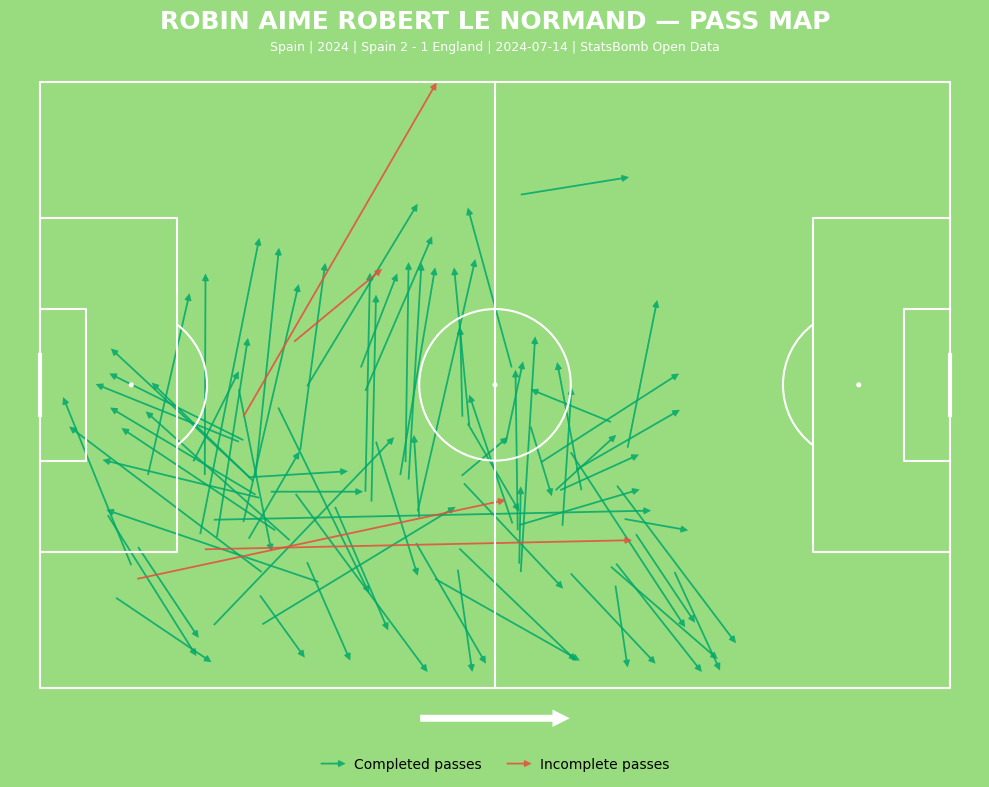

In [46]:
fig, ax = plot_pass_map(
    passes=player_passes_clean,
    player_name=PLAYER_NAME,
    team_name=TEAM_NAME,
    season_label=SEASON_NAME,
    match_label=MATCH_LABEL,
    match_date=MATCH_DATE,
    source=DATA_SOURCE
)

plt.show()

In [47]:
def slugify_text(text):
    replacements = {
        " ": "_",
        "-": "_",
        "í": "i",
        "é": "e",
        "è": "e",
        "ê": "e",
        "á": "a",
        "à": "a",
        "â": "a",
        "ó": "o",
        "ò": "o",
        "ô": "o",
        "ú": "u",
        "ù": "u",
        "û": "u",
        "ñ": "n",
        "ç": "c",
    }

    text = text.lower()

    for old, new in replacements.items():
        text = text.replace(old, new)

    text = "".join(
        character for character in text
        if character.isalnum() or character == "_"
    )

    while "__" in text:
        text = text.replace("__", "_")

    return text.strip("_")

In [48]:
player_slug = slugify_text(PLAYER_NAME)

PASS_MAP_OUTPUT = Path("../outputs") / f"{player_slug}_pass_map.png"

PASS_MAP_OUTPUT

WindowsPath('../outputs/robin_aime_robert_le_normand_pass_map.png')

In [50]:
fig.savefig(
    PASS_MAP_OUTPUT,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

In [51]:
PASS_MAP_OUTPUT.exists()

True

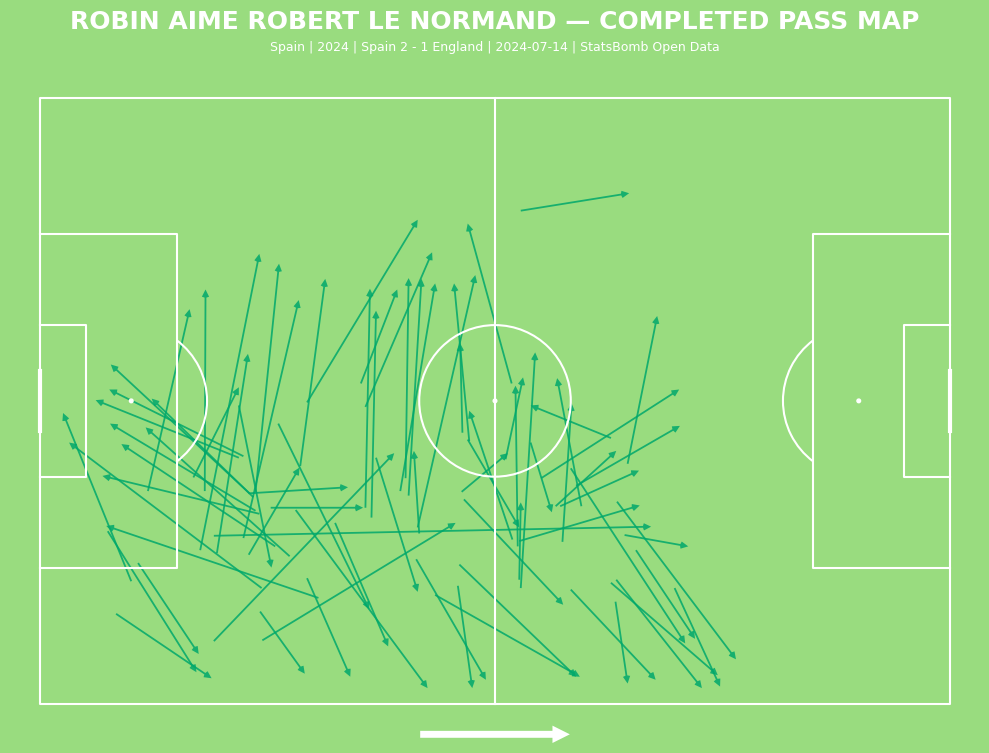

In [52]:
fig_completed, ax_completed = plot_pass_map(
    passes=completed,
    player_name=PLAYER_NAME,
    team_name=TEAM_NAME,
    season_label=SEASON_NAME,
    match_label=MATCH_LABEL,
    match_date=MATCH_DATE,
    source=DATA_SOURCE,
    title=f"{PLAYER_NAME.upper()} — COMPLETED PASS MAP",
    show_legend=False
)

plt.show()

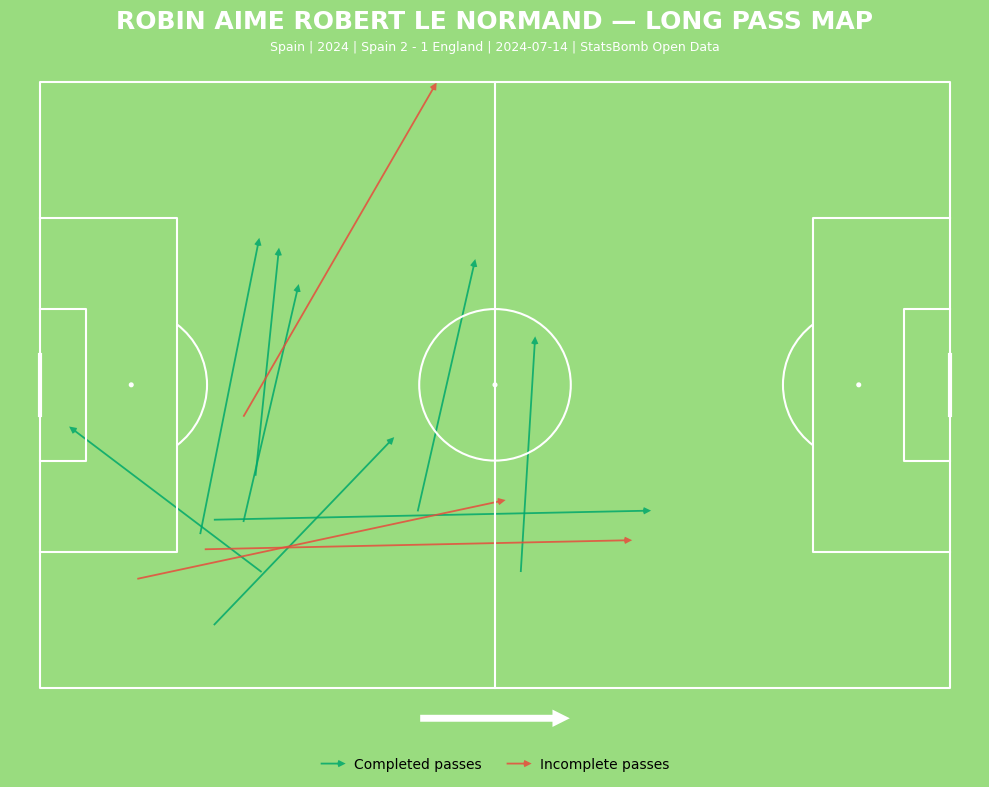

In [53]:
long_passes_df = player_passes_clean[
    player_passes_clean["is_long_pass"]
].copy()

fig_long, ax_long = plot_pass_map(
    passes=long_passes_df,
    player_name=PLAYER_NAME,
    team_name=TEAM_NAME,
    season_label=SEASON_NAME,
    match_label=MATCH_LABEL,
    match_date=MATCH_DATE,
    source=DATA_SOURCE,
    title=f"{PLAYER_NAME.upper()} — LONG PASS MAP"
)

plt.show()